# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deeepanshchandra/flyrank-aiml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Which existing content items should a content or SEO reviewer prioritize for review when limited review capacity is available, based only on signals that were observable by February 28, 2026?

The analysis supports the decision of which pages should be reviewed first for possible refresh, improvement, monitoring, or other intervention.

The specific outcome used for evaluation is whether a content item had zero measured GSC clicks during March 2026 (`went_dark`). The model is used as a ranking and decision-support tool, not as proof that a refresh will cause better performance.

In [1]:
%pip install -q duckdb huggingface_hub pandas scikit-learn matplotlib

import os
import getpass
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

def get_hf_token():
    token = os.environ.get("HF_TOKEN")
    if token:
        return token
    return getpass.getpass("Paste your Hugging Face READ token (hf_...): ")

token = get_hf_token()

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

con.execute("SET VARIABLE hf_token = ?", [token])

con.execute("""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN getvariable('hf_token')
    )
""")

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
DIM = f"{REL}/dim_content.parquet"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Warehouse connection ready.")
print("Feature window: February 2026")
print("Label window: March 2026")

Paste your Hugging Face READ token (hf_...): ··········
Warehouse connection ready.
Feature window: February 2026
Label window: March 2026


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This capstone uses the gated FlyRank internship warehouse release available through Hugging Face. The analysis uses the daily content-performance fact table and the content dimension table.

The feature window is February 1–28, 2026. February data is aggregated to one row per client × content item and represents information available at the February 28 decision point.

The label window is March 1–31, 2026. The target `went_dark` is defined as zero measured GSC clicks during March.

The analysis universe is restricted to published content items with usable GSC data that had at least 100 February impressions and 3 February clicks. This produced 29,700 content items across 31 clients.

The analysis excludes future March performance from the feature set. It also excludes fields that may contain post-decision information and downstream engagement fields that are not consistently measured. Client and content identifiers are used only for joins, grouping, and reporting, not as predictive features.

No client names, domains, URLs, keywords, private queries, credentials, or raw exports are included in the public paper.

In [2]:
# Build the February analysis universe and aggregate pre-decision features.

universe = con.sql(f"""
WITH feb_agg AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions_feb,
        SUM(gsc_clicks) AS clicks_feb,
        SUM(gsc_sum_position) AS sum_position_feb,

        AVG(gsc_avg_position) AS avg_position_mean_feb,
        STDDEV_SAMP(gsc_avg_position) AS position_std_feb,

        COUNT(DISTINCT CASE
            WHEN gsc_impressions > 0 THEN report_date
        END) AS days_with_impressions,

        COUNT(DISTINCT CASE
            WHEN gsc_impressions > 0 AND gsc_clicks = 0 THEN report_date
        END) AS zero_click_days,

        MIN(report_date) AS first_observed_day,
        MAX(report_date) AS last_observed_day

    FROM {FEB}
    WHERE gsc_data_available
    GROUP BY client_hash_id, content_hash_id

    HAVING SUM(gsc_impressions) >= 100
       AND SUM(gsc_clicks) >= 3
)

SELECT
    f.*,

    CASE
        WHEN f.impressions_feb > 0
        THEN f.clicks_feb * 1.0 / f.impressions_feb
        ELSE 0
    END AS ctr_feb,

    CASE
        WHEN f.impressions_feb > 0
        THEN f.sum_position_feb * 1.0 / f.impressions_feb
        ELSE NULL
    END AS avg_position_feb,

    d.content_type,
    d.keyword_token_count,
    d.url_char_count,
    d.category_count,
    d.content_created_date,
    d.search_volume,
    d.competition,
    d.competition_level,
    d.cpc,
    d.word_count,
    d.backlinks

FROM feb_agg f

JOIN read_parquet('{DIM}') d
    USING (client_hash_id, content_hash_id)

WHERE d.is_published
  AND NOT d.is_deleted
  AND d.content_created_date <= DATE '2026-02-28'
""").df()

# Content age at the February 28 decision point.
universe["content_age_days"] = (
    pd.Timestamp("2026-02-28")
    - pd.to_datetime(universe["content_created_date"])
).dt.days

print(f"Universe rows: {len(universe):,}")
print(f"Clients: {universe['client_hash_id'].nunique()}")

print("\nFeature preview:")
display(
    universe[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions_feb",
            "clicks_feb",
            "ctr_feb",
            "avg_position_feb",
            "days_with_impressions",
            "zero_click_days",
            "content_age_days",
            "word_count"
        ]
    ].head()
)

Universe rows: 29,700
Clients: 31

Feature preview:


,client_hash_id,content_hash_id,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,days_with_impressions,zero_click_days,content_age_days,word_count
0,client_3ffa76342f366962,content_5573434837db89c5,198.0,6.0,0.030303,7.318182,24,20,153,841
1,client_3ffa76342f366962,content_7b17975c58745266,102.0,5.0,0.049020,4.450980,26,21,29,2538
2,client_3ffa76342f366962,content_b89167cd03d6ffc1,178.0,6.0,0.033708,3.393258,26,20,29,2381
3,client_e547b89c05043229,content_eb42160708b4da7c,4802.0,5.0,0.001041,9.917118,28,23,344,2849
4,client_e547b89c05043229,content_4a630add28e014a5,7842.0,8.0,0.001020,19.141801,28,23,344,2784


In [3]:
# Build the March outcome separately from the February features.
# March data is used only for the target, never as a model feature.

march_label = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions_mar,
        SUM(gsc_clicks) AS clicks_mar
    FROM {MAR}
    WHERE gsc_data_available
    GROUP BY client_hash_id, content_hash_id
""").df()

capstone = universe.merge(
    march_label,
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

capstone[["impressions_mar", "clicks_mar"]] = (
    capstone[["impressions_mar", "clicks_mar"]].fillna(0)
)

# Target: zero measured GSC clicks during March.
capstone["went_dark"] = (
    capstone["clicks_mar"] == 0
).astype(int)

print(f"Rows: {len(capstone):,}")
print(f"Went-dark positives: {capstone['went_dark'].sum():,}")
print(f"Went-dark rate: {capstone['went_dark'].mean():.3f}")

print("\nLabel distribution:")
display(
    capstone["went_dark"]
    .value_counts()
    .rename_axis("went_dark")
    .reset_index(name="n")
)

Rows: 29,700
Went-dark positives: 1,506
Went-dark rate: 0.051

Label distribution:


,went_dark,n
0,0,28194
1,1,1506


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [4]:
# Leakage check and final feature selection.
# Every model input must be available by February 28, 2026.

feature_cols = [
    "impressions_feb",
    "clicks_feb",
    "ctr_feb",
    "avg_position_feb",
    "position_std_feb",
    "days_with_impressions",
    "zero_click_days",
    "content_age_days",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "backlinks",
]

# Confirm none of the March outcome fields are included.
future_or_label_cols = [
    "impressions_mar",
    "clicks_mar",
    "went_dark",
]

leakage_in_features = [
    col for col in future_or_label_cols
    if col in feature_cols
]

print("Feature columns:")
print(feature_cols)

print("\nFuture/label columns:")
print(future_or_label_cols)

print("\nLeakage found:")
print(leakage_in_features)

print("\nMissing values in model features:")
display(
    capstone[feature_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

assert len(leakage_in_features) == 0, "Leakage detected!"

Feature columns:
['impressions_feb', 'clicks_feb', 'ctr_feb', 'avg_position_feb', 'position_std_feb', 'days_with_impressions', 'zero_click_days', 'content_age_days', 'search_volume', 'competition', 'cpc', 'word_count', 'backlinks']

Future/label columns:
['impressions_mar', 'clicks_mar', 'went_dark']

Leakage found:
[]

Missing values in model features:


,missing
backlinks,12436
word_count,5454
search_volume,372
cpc,372
competition,372
position_std_feb,2
ctr_feb,0
clicks_feb,0
impressions_feb,0
avg_position_feb,0


In [5]:
# Client-grouped validation split.
# Validation clients are completely separated from training clients.

from sklearn.model_selection import GroupShuffleSplit

X = capstone[feature_cols].copy()
y = capstone["went_dark"].copy()
groups = capstone["client_hash_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, valid_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_valid = X.iloc[valid_idx].copy()

y_train = y.iloc[train_idx].copy()
y_valid = y.iloc[valid_idx].copy()

train_clients = set(groups.iloc[train_idx])
valid_clients = set(groups.iloc[valid_idx])

print(f"Training rows: {len(X_train):,}")
print(f"Validation rows: {len(X_valid):,}")

print(f"\nTraining clients: {len(train_clients)}")
print(f"Validation clients: {len(valid_clients)}")

print(
    f"\nClient overlap: "
    f"{len(train_clients.intersection(valid_clients))}"
)

print(f"\nTraining positive rate: {y_train.mean():.3f}")
print(f"Validation positive rate: {y_valid.mean():.3f}")

assert len(train_clients.intersection(valid_clients)) == 0

Training rows: 13,426
Validation rows: 16,274

Training clients: 24
Validation clients: 7

Client overlap: 0

Training positive rate: 0.046
Validation positive rate: 0.055


In [6]:
# W04-style hand-written baseline.
# This uses only February features and is evaluated on the same validation split.

baseline_valid = capstone.iloc[valid_idx].copy()

baseline_valid["baseline_score"] = (
    40
    * baseline_valid["content_age_days"].clip(0, 365)
    / 365
    + 30
    * (
        1
        - baseline_valid["ctr_feb"]
            .fillna(baseline_valid["ctr_feb"].median())
            .clip(0, 1)
    )
    + 30
    * (
        1
        - baseline_valid["avg_position_feb"]
            .fillna(baseline_valid["avg_position_feb"].median())
            .clip(1, 100)
        / 100
    )
)

baseline_scores = baseline_valid["baseline_score"].values
baseline_y = baseline_valid["went_dark"].values

# Ranking metrics.
k = min(50, len(baseline_valid))

top_k_idx = np.argsort(-baseline_scores)[:k]
precision_at_50_baseline = baseline_y[top_k_idx].mean()

baseline_auc = roc_auc_score(
    baseline_y,
    baseline_scores
)

baseline_ap = average_precision_score(
    baseline_y,
    baseline_scores
)

print(f"Baseline ROC AUC: {baseline_auc:.3f}")
print(f"Baseline Average Precision: {baseline_ap:.3f}")
print(f"Baseline Precision@50: {precision_at_50_baseline:.3f}")

Baseline ROC AUC: 0.554
Baseline Average Precision: 0.057
Baseline Precision@50: 0.020


In [7]:
# Train a Random Forest using the same client-holdout split.

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Fit imputation ONLY on the training data.
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_valid_imp = imputer.transform(X_valid)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_imp, y_train)

rf_valid_proba = rf.predict_proba(X_valid_imp)[:, 1]

rf_auc = roc_auc_score(
    y_valid,
    rf_valid_proba
)

rf_ap = average_precision_score(
    y_valid,
    rf_valid_proba
)

top_k_idx = np.argsort(-rf_valid_proba)[:50]

rf_precision_at_50 = y_valid.iloc[top_k_idx].mean()

rf_pred = (rf_valid_proba >= 0.5).astype(int)

rf_precision = precision_score(
    y_valid,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_valid,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_valid,
    rf_pred,
    zero_division=0
)

print(f"Random Forest ROC AUC: {rf_auc:.3f}")
print(f"Random Forest Average Precision: {rf_ap:.3f}")
print(f"Random Forest Precision@50: {rf_precision_at_50:.3f}")
print(f"Random Forest Precision: {rf_precision:.3f}")
print(f"Random Forest Recall: {rf_recall:.3f}")
print(f"Random Forest F1: {rf_f1:.3f}")

Random Forest ROC AUC: 0.778
Random Forest Average Precision: 0.172
Random Forest Precision@50: 0.280
Random Forest Precision: 0.143
Random Forest Recall: 0.503
Random Forest F1: 0.222


In [8]:
# Final model-vs-baseline results table.

results = pd.DataFrame([
    {
        "model": "W04 hand-written baseline",
        "roc_auc": baseline_auc,
        "average_precision": baseline_ap,
        "precision_at_50": precision_at_50_baseline,
    },
    {
        "model": "Random Forest",
        "roc_auc": rf_auc,
        "average_precision": rf_ap,
        "precision_at_50": rf_precision_at_50,
    }
])

print("Model comparison on the same client-held-out validation set:")
display(results.round(3))

Model comparison on the same client-held-out validation set:


,model,roc_auc,average_precision,precision_at_50
0,W04 hand-written baseline,0.554,0.057,0.02
1,Random Forest,0.778,0.172,0.28


In [9]:
# Inspect Random Forest feature importance.

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Random Forest feature importance:")
display(importance)

Random Forest feature importance:


,feature,importance
1,clicks_feb,0.268580
0,impressions_feb,0.199387
6,zero_click_days,0.186688
4,position_std_feb,0.096539
2,ctr_feb,0.056441
3,avg_position_feb,0.044884
7,content_age_days,0.040280
11,word_count,0.039901
5,days_with_impressions,0.031576
8,search_volume,0.013038


In [10]:
# Score the full February universe and create ranked recommendations.

X_all = capstone[feature_cols].copy()
X_all_imp = imputer.transform(X_all)

capstone["model_score"] = rf.predict_proba(X_all_imp)[:, 1]

# Rank highest-risk pages first.
recommendations = capstone.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = np.arange(1, len(recommendations) + 1)

# Simple action playbook based on model score.
recommendations["action"] = np.select(
    [
        recommendations["model_score"] >= 0.50,
        recommendations["model_score"] >= 0.25,
        recommendations["model_score"] >= 0.10,
    ],
    [
        "priority_review",
        "refresh_review",
        "monitor",
    ],
    default="monitor"
)

# One primary reason code based on the strongest observed warning signal.
recommendations["reason_code"] = np.select(
    [
        recommendations["zero_click_days"] >= 20,
        recommendations["ctr_feb"] < 0.01,
        recommendations["avg_position_feb"] > 20,
        recommendations["content_age_days"] >= 180,
    ],
    [
        "many_zero_click_days",
        "very_low_ctr",
        "weak_average_position",
        "older_content",
    ],
    default="model_risk"
)

ranked_queue = recommendations[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "model_score",
        "action",
        "reason_code",
        "impressions_feb",
        "clicks_feb",
        "ctr_feb",
        "avg_position_feb",
        "zero_click_days",
        "content_age_days"
    ]
].copy()

print(f"Ranked recommendations: {len(ranked_queue):,}")

print("\nTop 20 recommendations:")
display(ranked_queue.head(20))


Ranked recommendations: 29,700

Top 20 recommendations:


,rank,client_hash_id,content_hash_id,model_score,action,reason_code,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,zero_click_days,content_age_days
0,1,client_9958f0a7ae1df715,content_3b75c460a40fffca,0.922239,priority_review,many_zero_click_days,158.0,3.0,0.018987,41.784810,25,416
1,2,client_08a6a72ff48e62c0,content_01573a33dbe34105,0.920615,priority_review,many_zero_click_days,132.0,3.0,0.022727,23.068182,25,229
2,3,client_73cda7b4e4f265ea,content_cb67ca92aca85cc0,0.913998,priority_review,many_zero_click_days,108.0,3.0,0.027778,34.166667,24,381
3,4,client_08a6a72ff48e62c0,content_07c70f0084fa59ff,0.912632,priority_review,many_zero_click_days,149.0,4.0,0.026846,33.302013,24,297
4,5,client_9958f0a7ae1df715,content_3697ae261f896d64,0.906557,priority_review,many_zero_click_days,187.0,3.0,0.016043,22.197861,25,416
5,6,client_08a6a72ff48e62c0,content_fae4b4e9323aab1f,0.905014,priority_review,many_zero_click_days,147.0,3.0,0.020408,11.945578,24,319
6,7,client_62f4a7e64f5e0096,content_045b175d9cc397f1,0.904184,priority_review,many_zero_click_days,329.0,3.0,0.009119,8.750760,25,43
7,8,client_08a6a72ff48e62c0,content_6cc801b2bfcf5e12,0.904116,priority_review,many_zero_click_days,190.0,3.0,0.015789,16.973684,25,162
8,9,client_62f4a7e64f5e0096,content_c18258c8430db156,0.904043,priority_review,many_zero_click_days,167.0,3.0,0.017964,10.329341,25,72
9,10,client_9958f0a7ae1df715,content_96bd66f005f5c656,0.902060,priority_review,many_zero_click_days,202.0,3.0,0.014851,26.019802,26,416


In [11]:
# Summarize the ranked recommendation queue.

print("Action mix:")
display(
    ranked_queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="n")
)

print("\nReason-code mix:")
display(
    ranked_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="n")
)

print("\nTop-50 recommendation summary:")
display(
    ranked_queue.head(50)[
        [
            "rank",
            "model_score",
            "action",
            "reason_code",
            "impressions_feb",
            "clicks_feb",
            "ctr_feb",
            "avg_position_feb",
            "zero_click_days",
            "content_age_days"
        ]
    ].head(10)
)

Action mix:


,action,n
0,monitor,18739
1,priority_review,6031
2,refresh_review,4930



Reason-code mix:


,reason_code,n
0,many_zero_click_days,14215
1,very_low_ctr,13040
2,model_risk,1599
3,older_content,790
4,weak_average_position,56



Top-50 recommendation summary:


,rank,model_score,action,reason_code,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,zero_click_days,content_age_days
0,1,0.922239,priority_review,many_zero_click_days,158.0,3.0,0.018987,41.784810,25,416
1,2,0.920615,priority_review,many_zero_click_days,132.0,3.0,0.022727,23.068182,25,229
2,3,0.913998,priority_review,many_zero_click_days,108.0,3.0,0.027778,34.166667,24,381
3,4,0.912632,priority_review,many_zero_click_days,149.0,4.0,0.026846,33.302013,24,297
4,5,0.906557,priority_review,many_zero_click_days,187.0,3.0,0.016043,22.197861,25,416
5,6,0.905014,priority_review,many_zero_click_days,147.0,3.0,0.020408,11.945578,24,319
6,7,0.904184,priority_review,many_zero_click_days,329.0,3.0,0.009119,8.750760,25,43
7,8,0.904116,priority_review,many_zero_click_days,190.0,3.0,0.015789,16.973684,25,162
8,9,0.904043,priority_review,many_zero_click_days,167.0,3.0,0.017964,10.329341,25,72
9,10,0.902060,priority_review,many_zero_click_days,202.0,3.0,0.014851,26.019802,26,416


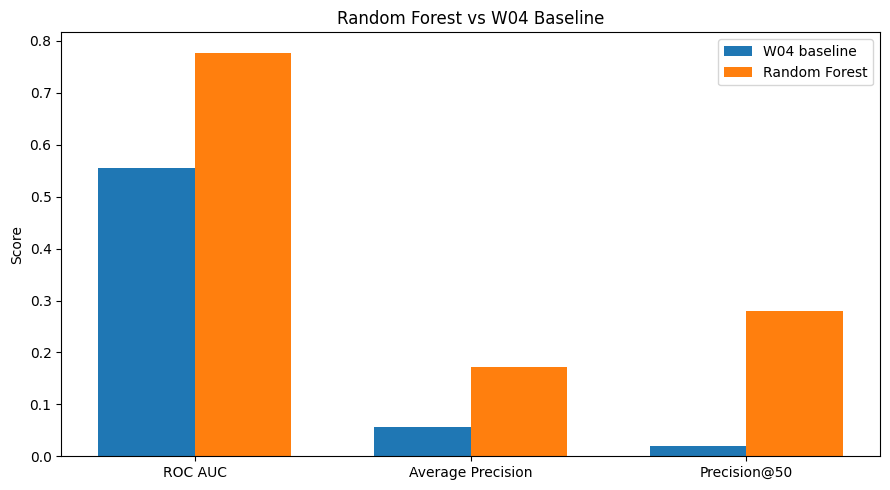

Saved: work/outputs/capstone_charts/model_vs_baseline.png


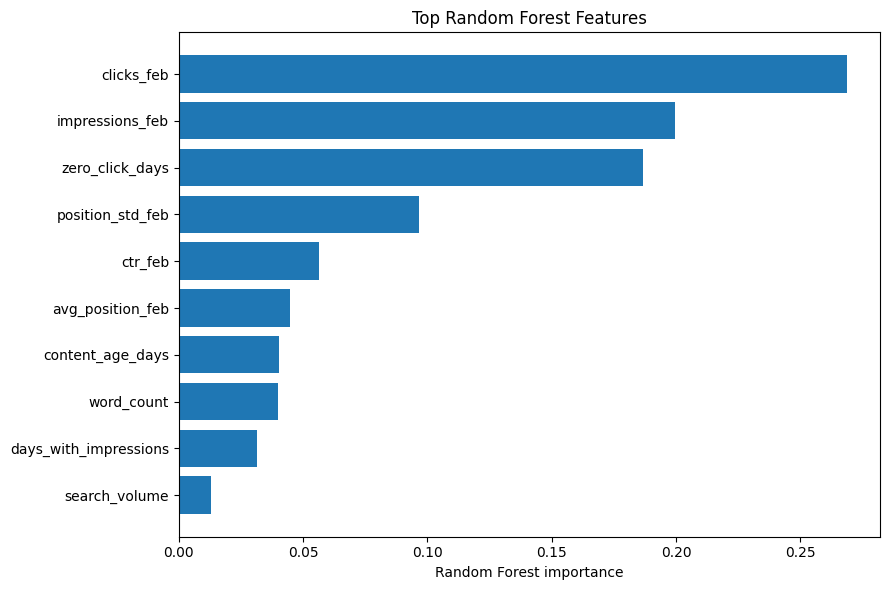

Saved: work/outputs/capstone_charts/feature_importance.png


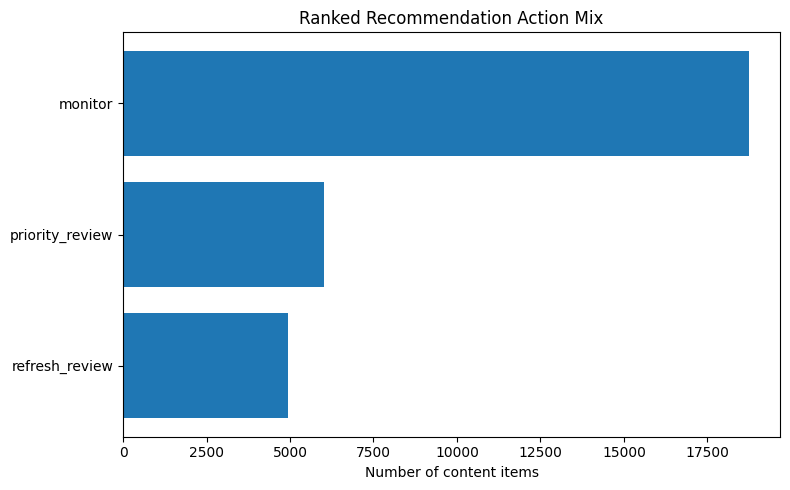

Saved: work/outputs/capstone_charts/action_mix.png


In [12]:
# Create the main capstone figures.

from pathlib import Path

chart_dir = Path("work/outputs/capstone_charts")
chart_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Chart 1: Model vs baseline
# ---------------------------------------------------------

metrics = ["ROC AUC", "Average Precision", "Precision@50"]
baseline_values = [
    baseline_auc,
    baseline_ap,
    precision_at_50_baseline
]
rf_values = [
    rf_auc,
    rf_ap,
    rf_precision_at_50
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="W04 baseline"
)

plt.bar(
    x + width / 2,
    rf_values,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest vs W04 Baseline")
plt.legend()
plt.tight_layout()

model_chart = chart_dir / "model_vs_baseline.png"
plt.savefig(model_chart, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {model_chart}")


# ---------------------------------------------------------
# Chart 2: Feature importance
# ---------------------------------------------------------

top_features = importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest importance")
plt.title("Top Random Forest Features")
plt.tight_layout()

importance_chart = chart_dir / "feature_importance.png"
plt.savefig(importance_chart, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {importance_chart}")


# ---------------------------------------------------------
# Chart 3: Action mix
# ---------------------------------------------------------

action_counts = (
    ranked_queue["action"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    action_counts.index,
    action_counts.values
)

plt.xlabel("Number of content items")
plt.title("Ranked Recommendation Action Mix")
plt.tight_layout()

action_chart = chart_dir / "action_mix.png"
plt.savefig(action_chart, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {action_chart}")

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The Random Forest was evaluated against the W04 hand-written baseline using the same client-held-out validation split.

The Random Forest performed better on all three ranking metrics. It achieved a ROC AUC of 0.778 compared with 0.554 for the baseline, average precision of 0.172 compared with 0.057, and Precision@50 of 0.280 compared with 0.020.

Precision@50 is the most directly relevant metric for this use case because the goal is to help a reviewer prioritize a small number of pages. On the validation set, the Random Forest placed 14 went-dark pages among its top 50 recommendations, while the baseline placed only 1.

These results are measured on the held-out clients and provide directional evidence that the model ranking is more useful than the tested hand-written rule for this validation setup.

In [ ]:
# Model comparison on the same client-held-out validation set.

results = pd.DataFrame([
    {
        "model": "W04 hand-written baseline",
        "roc_auc": baseline_auc,
        "average_precision": baseline_ap,
        "precision_at_50": precision_at_50_baseline,
    },
    {
        "model": "Random Forest",
        "roc_auc": rf_auc,
        "average_precision": rf_ap,
        "precision_at_50": rf_precision_at_50,
    }
])

display(results.round(3))

,model,roc_auc,average_precision,precision_at_50
0,W04 hand-written baseline,0.554,0.057,0.02
1,Random Forest,0.778,0.172,0.28


## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis predicts a measured March GSC outcome from February signals. A `went_dark` label means zero measured GSC clicks during March; it does not prove that a page received no real-world traffic or that the page was actually removed from search visibility.

The model is evaluated using a client-held-out split, but the analysis covers one February feature window and one March outcome window. Performance may therefore change on other periods or client populations.

The model identifies pages for review. It does not prove why a page declined, predict Google's ranking algorithm, or establish that refreshing a page will improve traffic or rankings.

The ranked actions and reason codes are decision-support outputs. A human reviewer should check the underlying page context before taking an editorial or SEO action.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The Random Forest was used to rank all 29,700 eligible content items by estimated probability of the March `went_dark` outcome.

The ranked queue is intended to help a reviewer decide where to spend limited review time first. Higher-scored items receive higher review priority, while lower-scored items can be monitored rather than immediately reviewed.

The action playbook contains three levels: `priority_review`, `refresh_review`, and `monitor`.

The queue contains 6,031 priority-review items, 4,930 refresh-review items, and 18,739 monitor items.

The most common reason codes are `many_zero_click_days` (14,215 items) and `very_low_ctr` (13,040 items). These reason codes are simple rule-based descriptions attached to the model ranking. They are review prompts, not causal explanations or automatic publishing instructions.

A practical workflow is to inspect priority-review pages first, verify their current search and editorial context, then decide whether to refresh, improve, monitor, or take no action.

In [14]:
# Build and display the final ranked recommendation queue.

print(f"Ranked recommendations: {len(ranked_queue):,}")

print("\nAction mix:")
display(
    ranked_queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="n")
)

print("\nReason-code mix:")
display(
    ranked_queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="n")
)

print("\nTop 20 recommendations:")
display(ranked_queue.head(20))

Ranked recommendations: 29,700

Action mix:


,action,n
0,monitor,18739
1,priority_review,6031
2,refresh_review,4930



Reason-code mix:


,reason_code,n
0,many_zero_click_days,14215
1,very_low_ctr,13040
2,model_risk,1599
3,older_content,790
4,weak_average_position,56



Top 20 recommendations:


,rank,client_hash_id,content_hash_id,model_score,action,reason_code,impressions_feb,clicks_feb,ctr_feb,avg_position_feb,zero_click_days,content_age_days
0,1,client_9958f0a7ae1df715,content_3b75c460a40fffca,0.922239,priority_review,many_zero_click_days,158.0,3.0,0.018987,41.784810,25,416
1,2,client_08a6a72ff48e62c0,content_01573a33dbe34105,0.920615,priority_review,many_zero_click_days,132.0,3.0,0.022727,23.068182,25,229
2,3,client_73cda7b4e4f265ea,content_cb67ca92aca85cc0,0.913998,priority_review,many_zero_click_days,108.0,3.0,0.027778,34.166667,24,381
3,4,client_08a6a72ff48e62c0,content_07c70f0084fa59ff,0.912632,priority_review,many_zero_click_days,149.0,4.0,0.026846,33.302013,24,297
4,5,client_9958f0a7ae1df715,content_3697ae261f896d64,0.906557,priority_review,many_zero_click_days,187.0,3.0,0.016043,22.197861,25,416
5,6,client_08a6a72ff48e62c0,content_fae4b4e9323aab1f,0.905014,priority_review,many_zero_click_days,147.0,3.0,0.020408,11.945578,24,319
6,7,client_62f4a7e64f5e0096,content_045b175d9cc397f1,0.904184,priority_review,many_zero_click_days,329.0,3.0,0.009119,8.750760,25,43
7,8,client_08a6a72ff48e62c0,content_6cc801b2bfcf5e12,0.904116,priority_review,many_zero_click_days,190.0,3.0,0.015789,16.973684,25,162
8,9,client_62f4a7e64f5e0096,content_c18258c8430db156,0.904043,priority_review,many_zero_click_days,167.0,3.0,0.017964,10.329341,25,72
9,10,client_9958f0a7ae1df715,content_96bd66f005f5c656,0.902060,priority_review,many_zero_click_days,202.0,3.0,0.014851,26.019802,26,416


In [15]:
# Save the ranked recommendation queue.

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

queue_path = output_dir / "capstone_ranked_recommendations.csv"

ranked_queue.to_csv(
    queue_path,
    index=False
)

print(f"Saved ranked queue: {queue_path}")

Saved ranked queue: work/outputs/capstone_ranked_recommendations.csv


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts

The notebook generates three visual artifacts for the research paper:

1. A comparison of the Random Forest and the W04 hand-written baseline.
2. The top Random Forest feature importances.
3. The distribution of recommended actions across the full analysis universe.

The figures are generated directly from the capstone run so that the reported results can be reproduced from the notebook.

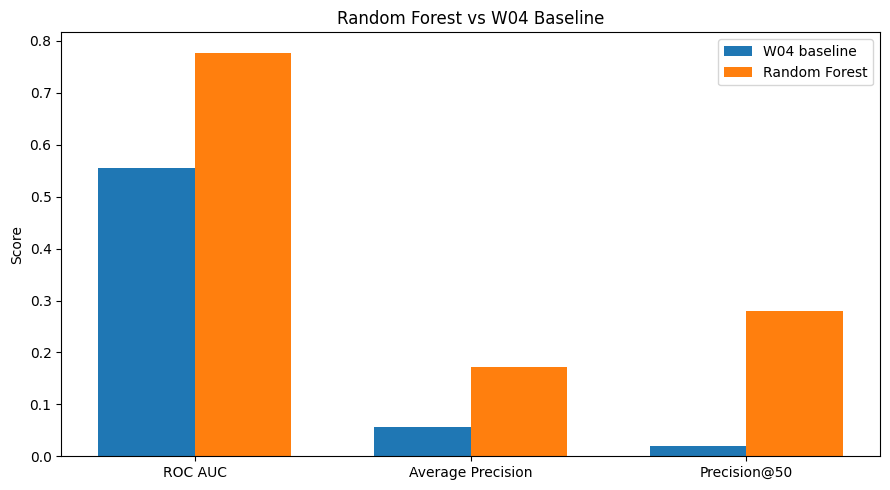

Saved: work/outputs/capstone_charts/model_vs_baseline.png


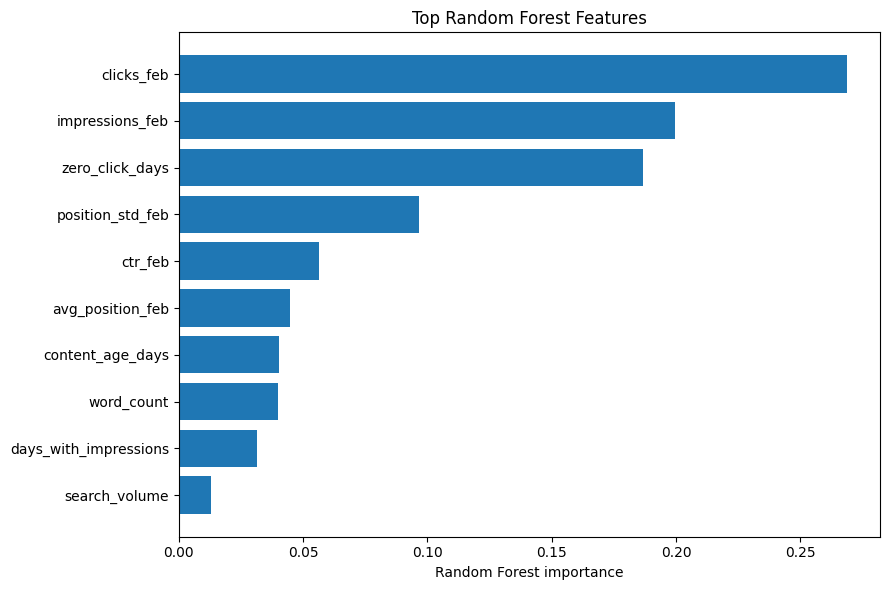

Saved: work/outputs/capstone_charts/feature_importance.png


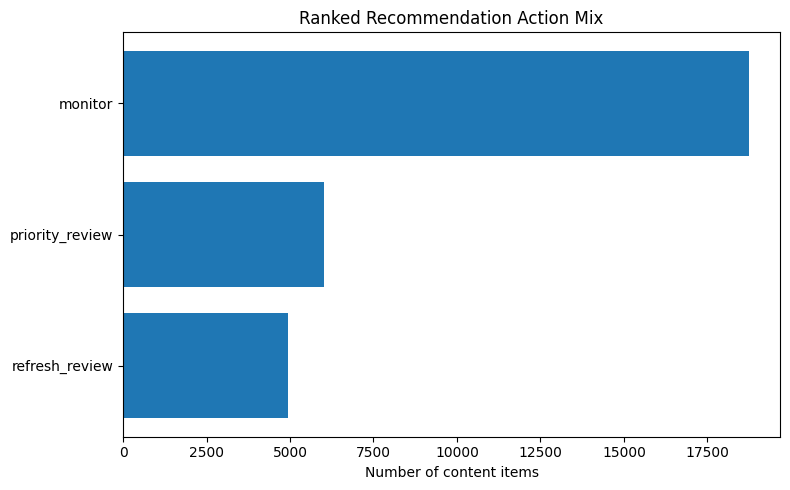

Saved: work/outputs/capstone_charts/action_mix.png


In [16]:
# Generate the three main figures used by the research paper.

from pathlib import Path

chart_dir = Path("work/outputs/capstone_charts")
chart_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Model vs baseline
# ---------------------------------------------------------

metrics = ["ROC AUC", "Average Precision", "Precision@50"]

baseline_values = [
    baseline_auc,
    baseline_ap,
    precision_at_50_baseline
]

rf_values = [
    rf_auc,
    rf_ap,
    rf_precision_at_50
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="W04 baseline"
)

plt.bar(
    x + width / 2,
    rf_values,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest vs W04 Baseline")
plt.legend()
plt.tight_layout()

model_chart = chart_dir / "model_vs_baseline.png"
plt.savefig(model_chart, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {model_chart}")


# ---------------------------------------------------------
# 2. Feature importance
# ---------------------------------------------------------

top_features = importance.head(10).sort_values("importance")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Random Forest importance")
plt.title("Top Random Forest Features")
plt.tight_layout()

importance_chart = chart_dir / "feature_importance.png"
plt.savefig(importance_chart, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {importance_chart}")


# ---------------------------------------------------------
# 3. Action mix
# ---------------------------------------------------------

action_counts = (
    ranked_queue["action"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    action_counts.index,
    action_counts.values
)

plt.xlabel("Number of content items")
plt.title("Ranked Recommendation Action Mix")
plt.tight_layout()

action_chart = chart_dir / "action_mix.png"
plt.savefig(action_chart, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved: {action_chart}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
